### Down load data from database

In [1]:
import pandas as pd
from sqlalchemy import create_engine, inspect
import numpy as np
from datetime import datetime

In [2]:
CONN = create_engine('mssql+pyodbc://@GSB_Prod?TrustedConnection=True', connect_args={"timeout": 120})

_table = 'cftc_cot_disag'
cmd = 'SOYBEAN OIL - CHICAGO BOARD OF TRADE'
query =   f"SELECT * from {_table} where Market_and_Exchange_Names = '{cmd}'"
_df_disag = pd.read_sql(query, con=CONN)

CONN.dispose()
_df_disag  = _df_disag[['Report_Date_as_YYYY-MM-DD',
                        'Open_Interest_All',
                        'Prod_Merc_Positions_Long_All',
                        'Prod_Merc_Positions_Short_All',
                        'Swap_Positions_Long_All','Swap__Positions_Short_All','Swap__Positions_Spread_All','M_Money_Positions_Long_All',
                        'M_Money_Positions_Short_All','M_Money_Positions_Spread_All','Other_Rept_Positions_Long_All','Other_Rept_Positions_Short_All',
'Other_Rept_Positions_Spread_All',
'Tot_Rept_Positions_Long_All',
'Tot_Rept_Positions_Short_All',
'NonRept_Positions_Long_All',
'NonRept_Positions_Short_All',
'FutOnly_or_Combined']]
_df_disag.columns = ['date',
                        'oi',
                        'prod_long',
                        'prod_short',
                        'swap_long','swap_short','swap_spread','mm_long',
                        'mm_short','mm_spread','other_rep_long','other_rep_short',
'other_rep_spread',
'total_rep_long',
'total_rep_short',
'non_rep_long',
'non_rep_short',
'FutOnly_or_Combined']
_df_disag.sort_values(by='date', inplace=True)
_df_disag.to_csv('cot_disag.csv', index=False)
_df_disag.head()


,date,oi,prod_long,prod_short,swap_long,swap_short,swap_spread,mm_long,mm_short,mm_spread,other_rep_long,other_rep_short,other_rep_spread,total_rep_long,total_rep_short,non_rep_long,non_rep_short,FutOnly_or_Combined
1347,2013-01-08,303230,76775,126058,81656,117,5920,42107,79914,17342,26271,15802,23525,273596,268678,29634,34552,FutOnly
1299,2013-01-08,343794,89157,140209,83032,0,6972,41686,78702,27038,24403,14719,40630,312919,308271,30875,35524,Combined
1346,2013-01-15,318829,75449,135946,86670,0,6873,41063,74990,24083,26035,17196,25342,285515,284430,33314,34399,FutOnly
1298,2013-01-15,360034,86658,150314,88068,0,7870,41410,73905,33309,24401,15664,43544,325261,324606,34773,35428,Combined
1345,2013-01-22,317191,66613,142314,87202,0,7640,50348,62843,20453,20947,22259,25920,279123,281429,38068,35762,FutOnly


In [3]:
CONN = create_engine('mssql+pyodbc://@GSB_Prod?TrustedConnection=True', connect_args={"timeout": 120})

_table = 'cftc_cot_combined'
cmd = 'SOYBEAN OIL - CHICAGO BOARD OF TRADE'
query =   f"SELECT * from {_table} where [Market and Exchange Names] = '{cmd}'"
_df_combined = pd.read_sql(query, con=CONN)

CONN.dispose()
_df_combined = _df_combined[['As of Date in Form YYYY-MM-DD',
'Open Interest (All)',
'Noncommercial Positions-Long (All)',
'Noncommercial Positions-Short (All)',
'Noncommercial Positions-Spreading (All)',
'Commercial Positions-Long (All)',
'Commercial Positions-Short (All)',
' Total Reportable Positions-Long (All)',
'Total Reportable Positions-Short (All)',
'Nonreportable Positions-Long (All)',
'Nonreportable Positions-Short (All)',
'FutOnly_or_Combined']]
_df_combined.columns = ['date',
                        'oi',
                        'non_commercial_long',
                        'non_commercial_short',
                        'non_commercial_spread',
                        'commercial_long',
                        'commercial_short',
                        'total_rep_long',
                        'total_rep_short',
                        'non_rep_long',
'non_rep_short','FutOnly_or_Combined']
                        
_df_combined.sort_values(by='date', inplace=True)
_df_combined.head()
_df_combined.to_csv('cot_combined.csv', index=False)

In [4]:

_table = 'cftc_cot_index'
cmd = 'SOYBEAN OIL - CHICAGO BOARD OF TRADE'
query =   f"SELECT * from {_table} where Market_and_Exchange_Names = '{cmd}'"
_df_index = pd.read_sql(query, con=CONN)

CONN.dispose()
_df_index = _df_index[[
'As_of_Date_In_Form_YYYY-MM-DD',
'Open_Interest_All',
'NComm_Positions_Long_All_NoCIT',
'NComm_Positions_Short_All_NoCIT',
'NComm_Postions_Spread_All_NoCIT',
'Comm_Positions_Long_All_NoCIT',
'Comm_Positions_Short_All_NoCIT',
'Tot_Rept_Positions_Long_All',
'Tot_Rept_Positions_Short_All',
'NonRept_Positions_Long_All',
'NonRept_Positions_Short_All',
'CIT_Positions_Long_All',
'CIT_Positions_Short_All',
'FutOnly_or_Combined'
]]
_df_index.columns = ['date',
                        'oi',
                        'non_commercial_long',
                        'non_commercial_short',
                        'non_commercial_spread',
                        'commercial_long',
                        'commercial_short',
                        'total_rep_long',
                        'total_rep_short',
                        'non_rep_long',
                        'non_rep_short',
                        'cit_long',
                        'cit_short',
                        'FutOnly_or_Combined']
_df_index.sort_values(by='date', inplace=True)        
_df_index.head()
_df_index.to_csv('cot_index.csv', index=False)

### load data from local

In [5]:
import pandas as pd
_df_disag= pd.read_csv('cot_disag.csv')
_df_disag = _df_disag[_df_disag['FutOnly_or_Combined'] == 'Combined']
_df_combined= pd.read_csv('cot_combined.csv')
_df_combined = _df_combined[_df_combined['FutOnly_or_Combined'] == 'Combined']
_df_index= pd.read_csv('cot_index.csv')

_df_combined['date'] = pd.to_datetime(_df_combined['date'])
_df_disag['date'] = pd.to_datetime(_df_disag['date'])
_df_combined.set_index('date', inplace=True)
_df_disag.set_index('date', inplace=True)
_df_index['date'] = pd.to_datetime(_df_index['date'])
_df_index.set_index('date', inplace=True)


<Axes: xlabel='date'>

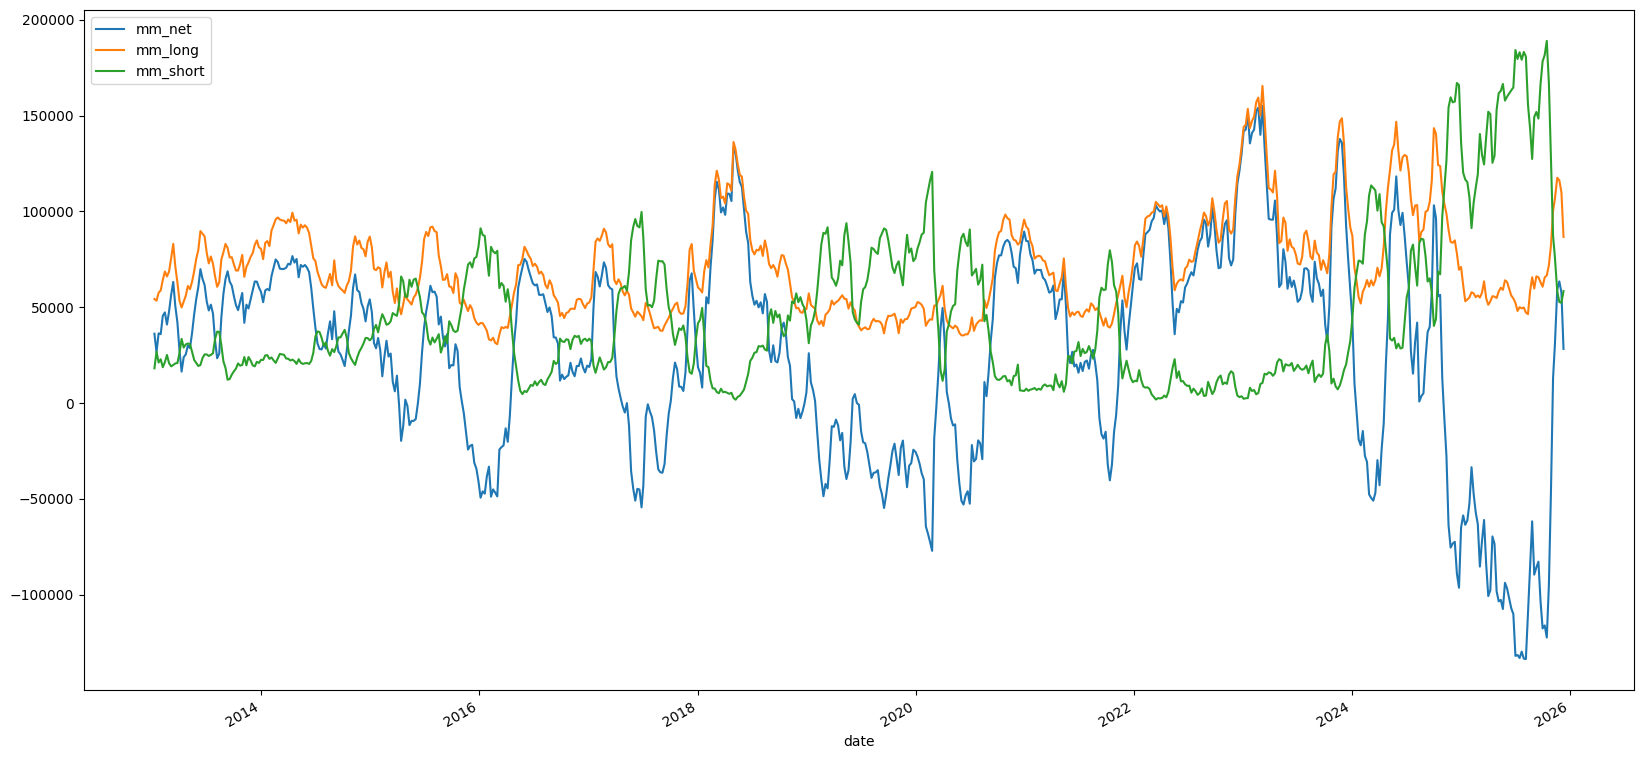

In [3]:
_df_disag['mm_net'] = _df_disag['mm_long'] - _df_disag['mm_short']
_df_disag[['mm_net','mm_long','mm_short']].plot(figsize=(20,10))

<Axes: xlabel='date'>

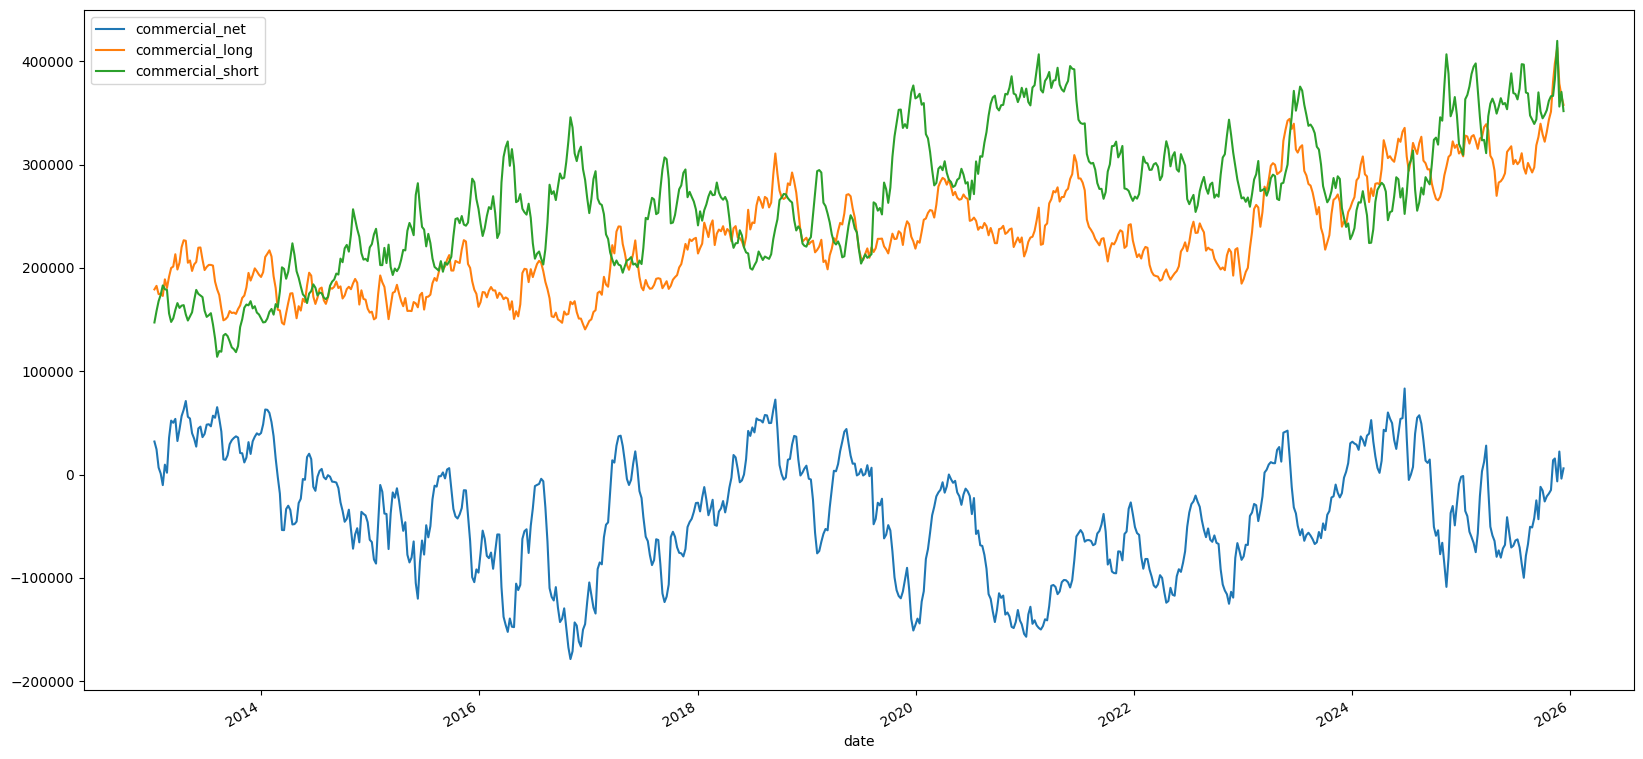

In [6]:
_df_combined['commercial_net'] = _df_combined['commercial_long'] - _df_combined['commercial_short']
_df_combined[['commercial_net','commercial_long','commercial_short']].plot(figsize=(20,10))

In [7]:
_df_index['commercial_net'] = _df_index['commercial_long'] - _df_index['commercial_short']
_df_index['non_commercial_net'] = _df_index['non_commercial_long'] - _df_index['non_commercial_short']
# _df_index[['commercial_net','commercial_long','commercial_short']].plot(figsize=(20,10))

In [8]:
_df_combined['non_commercial_net'] = _df_combined['non_commercial_long'] - _df_combined['non_commercial_short']
_df_combined[['non_commercial_net']].loc['2021-05-01':'2021-07-01']

,non_commercial_net
date,
2021-05-04,85032
2021-05-11,84414
2021-05-18,85680
2021-05-25,88589
2021-06-01,91526
2021-06-08,84541
2021-06-15,67738
2021-06-22,52930
2021-06-29,48696


In [9]:
_df_index['cit_net'] = _df_index['cit_long'] - _df_index['cit_short']
_df_index['cit_net'] = _df_index['cit_long'] - _df_index['cit_short']
_df_index[['cit_net','non_commercial_net']].loc['2021-05-01':'2021-07-01']

,cit_net,non_commercial_net
date,,
2021-05-04,124621,49670
2021-05-11,126502,48968
2021-05-18,125792,50930
2021-05-25,126371,53333
2021-06-01,128011,56820
2021-06-08,123413,54738
2021-06-15,122040,40429
2021-06-22,120152,24647
2021-06-29,125012,18407


### Generate Signals

In [10]:
import pandas as pd
import numpy as np
from datetime import datetime
# ----------------------------
# Helpers
# ----------------------------
def zscore(s: pd.Series, window: int = 156) -> pd.Series:
    """Rolling z-score, ~3 years of weekly data default (156)."""
    mu = s.rolling(window, min_periods=20).mean()
    sd = s.rolling(window, min_periods=20).std(ddof=0)
    return (s - mu) / sd

def winsorize(s: pd.Series, p: float = 0.01) -> pd.Series:
    lo, hi = s.quantile(p), s.quantile(1 - p)
    return s.clip(lo, hi)

def safe_div(a, b):
    b = b.replace(0, np.nan)
    return a / b

# ----------------------------
# Core: build unified weekly panel
# ----------------------------
def build_panel(
    legacy: pd.DataFrame,
    disagg: pd.DataFrame,
    cit: pd.DataFrame,
    mode: str = "F+O",   # "F+O" recommended, or "F" to force futures-only
    cit_has_only_FO: bool = True,  # True if your CIT table is only Futures+Options
):
    """
    Returns a merged panel with:
      - Legacy Commercial long/short
      - Disagg SwapDealer long/short
      - Disagg ManagedMoney long/short
      - CIT long/short (scaled if needed)
      - OI (matching chosen mode)
      - PMPU approximations (Commercial - SwapDealer, optionally - CIT)
    """

    # ---- expected columns (edit these to match your files) ----
    COLMAP = {
        # common
        "date": "date",

        # open interest
        "legacy_oi": "oi",
        "disagg_oi": "oi",

        # legacy commercial
        "legacy_com_long": "commercial_long",
        "legacy_com_short": "commercial_short",
        "legacy_non_com_long": "non_commercial_long",
        "legacy_non_com_short": "non_commercial_short",


                        # 'non_commercial_long',
                        # 'non_commercial_short',
                        # 'non_commercial_spread',

        # disaggregated
        "swap_long": "swap_long",
        "swap_short": "swap_short",
        "mm_long": "mm_long",
        "mm_short": "mm_short",

        # optional: spread (if you have it)
        "mm_spread": "mm_spread",
        "swap_spread": "swap_spread",
        "or_spread": "other_rep_spread",

        # CIT supplemental (often long/short/spread may exist depending on dataset)
        "cit_long": "cit_long",
        "cit_short": "cit_short",
        "cit_spread": "cit_spreading",
        "cit_non_com_long": "non_commercial_long",
        "cit_non_com_short": "non_commercial_short",
        "cit_oi": "oi",  # if available; else we'll use legacy/disagg OI

        #  'non_commercial_long',
        #                 'non_commercial_short',
    }

    # ---- standardize ----
    for df in (legacy, disagg, cit):
        df[COLMAP["date"]] = pd.to_datetime(df[COLMAP["date"]])
        df.sort_values(COLMAP["date"], inplace=True)

    legacy = legacy.set_index(COLMAP["date"])
    disagg = disagg.set_index(COLMAP["date"])
    cit = cit.set_index(COLMAP["date"])

    # ---- merge on date ----
    panel = legacy[[COLMAP["legacy_oi"], COLMAP["legacy_com_long"], COLMAP["legacy_com_short"],COLMAP["legacy_non_com_long"],COLMAP["legacy_non_com_short"]]].rename(
        columns={
            COLMAP["legacy_oi"]: "oi_legacy",
            COLMAP["legacy_com_long"]: "legacy_com_long",
            COLMAP["legacy_com_short"]: "legacy_com_short",
            COLMAP["legacy_non_com_long"]: "legacy_non_com_long",
            COLMAP["legacy_non_com_short"]: "legacy_non_com_short",
        }
    ).join(
        disagg[[COLMAP["disagg_oi"], COLMAP["swap_long"], COLMAP["swap_short"], COLMAP["mm_long"], COLMAP["mm_short"],COLMAP['or_spread']]].rename(
            columns={
                COLMAP["disagg_oi"]: "oi_disagg",
                COLMAP["swap_long"]: "swap_long",
                COLMAP["swap_short"]: "swap_short",
                COLMAP["mm_long"]: "mm_long",
                COLMAP["mm_short"]: "mm_short",
                COLMAP['or_spread']: "or_spread",
            }
        ),
        how="inner"
    ).join(
        cit[[COLMAP["cit_long"], COLMAP["cit_short"],COLMAP["cit_non_com_long"], COLMAP["cit_non_com_short"]]].rename(
            columns={
                COLMAP["cit_long"]: "cit_long", 
                COLMAP["cit_short"]: "cit_short",
                COLMAP["cit_non_com_long"]: "cit_non_com_long",
                COLMAP["cit_non_com_short"]: "cit_non_com_short",
            }
        ),
        how="left"
    )

    if mode.upper() == "F+O":
        panel["oi"] = panel["oi_disagg"].copy()
    else:
        panel["oi"] = panel["oi_disagg"].copy()

    if mode.upper() == "F" and cit_has_only_FO:
        # Need oi_futures and oi_FO. If you don't have both, you must supply them.
        # Here we assume:
        #   panel["oi"] = futures-only OI
        #   panel["oi_disagg"] could be FO OI if you loaded FO disagg; otherwise vice versa.
        # Practical: provide both columns yourself or edit below.
        # We'll attempt a generic scaling using legacy vs disagg if they differ.
        oi_f = panel["oi_legacy"]  # assume legacy OI corresponds to futures-only
        oi_fo = panel["oi_disagg"] # assume disagg OI corresponds to futures+options
        scale = safe_div(oi_f, oi_fo).clip(0.2, 2.0)  # guardrails
        panel["cit_long"] = panel["cit_long"] * scale
        panel["cit_short"] = panel["cit_short"] * scale

    # ---- core constructions ----
    panel["legacy_com_net"] = panel["legacy_com_long"] - panel["legacy_com_short"]
    panel["legacy_non_com_net"] = panel["legacy_non_com_long"] - panel["legacy_non_com_short"]
    panel["cit_non_com_net"] = panel["cit_non_com_long"] - panel["cit_non_com_short"]

    # "cit_non_com_long"], COLMAP["cit_non_com_short"
    panel["mm_net"] = panel["mm_long"] - panel["mm_short"]
    panel["swap_net"] = panel["swap_long"] - panel["swap_short"]
    panel["cit_net"] = panel["cit_long"] - panel["cit_short"]
    temp = panel[["mm_net"]].copy()
    temp['year'] = temp.index.year
    temp['month'] = temp.index.month

    normalize_start = datetime.now()-pd.DateOffset(years=2)
    normalize_df = temp[(temp.index< normalize_start) ].copy()
    normalize_mtx = normalize_df[['mm_net','month']].groupby(['month']).mean()
    normalize_mtx_std = normalize_df[['mm_net','month']].groupby(['month']).std()
    normalize_mtx = normalize_mtx.rename(columns=lambda x: f'{x}_monthly_mean')
    normalize_mtx_std = normalize_mtx_std.rename(columns=lambda x: f'{x}_monthly_std')
    monthly_stats = pd.merge(normalize_mtx, normalize_mtx_std, left_index=True, right_index=True)
    df_normalized = temp.merge(monthly_stats, how='left', left_on='month', right_index=True)
    # Calculate z-score
    df_normalized['mm_net_desea'] = (
        (df_normalized['mm_net'] - df_normalized['mm_net_monthly_mean']) / 
        df_normalized['mm_net_monthly_std'].replace(0, np.nan)  # Replace 0 with NaN to avoid division by zero
    )
    panel['mm_net_desea'] = df_normalized['mm_net_desea']
    # PMPU proxy = Legacy Commercial - Swap Dealers (publicly observable approximation)
    panel["pmpu_long"] = panel["legacy_com_long"] - panel["swap_long"]
    panel["pmpu_short"] = panel["legacy_com_short"] - panel["swap_short"]
    panel["pmpu_net"] = panel["pmpu_long"] - panel["pmpu_short"]

    # Optional "de-indexing" adjustment: subtract CIT from PMPU (only if you want)
    # This is a harsher adjustment; use carefully.
    panel["pmpu_ex_cit_net"] = panel["pmpu_net"] - panel["cit_net"]

    # shares
    panel["mm_short_share"] = safe_div(panel["mm_short"], panel["oi"])
    panel["pmpu_short_share"] = safe_div(panel["pmpu_short"], panel["oi"])
    panel["cit_long_share"] = safe_div(panel["cit_long"], panel["oi"])
    panel["mm_net_share"] = safe_div(panel["mm_net"], panel["oi"])
    panel["legacy_com_net_share"] = safe_div(panel["legacy_com_net"], panel["oi"])
    temp = panel[["mm_net_share"]].copy()
    temp['year'] = temp.index.year
    temp['month'] = temp.index.month
    normalize_start = datetime.now()-pd.DateOffset(years=2)
    normalize_df = temp[(temp.index< normalize_start) ].copy()
    normalize_mtx = normalize_df[['mm_net_share','month']].groupby(['month']).mean()
    normalize_mtx_std = normalize_df[['mm_net_share','month']].groupby(['month']).std()
    normalize_mtx = normalize_mtx.rename(columns=lambda x: f'{x}_monthly_mean')
    normalize_mtx_std = normalize_mtx_std.rename(columns=lambda x: f'{x}_monthly_std')
    monthly_stats = pd.merge(normalize_mtx, normalize_mtx_std, left_index=True, right_index=True)
    df_normalized = temp.merge(monthly_stats, how='left', left_on='month', right_index=True)
    # Calculate z-score
    df_normalized['mm_net_share_desea'] = (
        (df_normalized['mm_net_share'] - df_normalized['mm_net_share_monthly_mean']) / 
        df_normalized['mm_net_share_monthly_std'].replace(0, np.nan)  # Replace 0 with NaN to avoid division by zero
    )
    panel['mm_net_share_desea'] = df_normalized['mm_net_share_desea']

    return panel


def compute_signals(panel: pd.DataFrame):
    out = panel.copy()
    out["mm_zscore"]= zscore(out["mm_net"])
    out["mm_zscore_speed"] = out["mm_zscore"].diff(1)

    out['mm_net_oi'] = safe_div(out['mm_net'], out['oi'])
    out["mm_oi_zscore"]= zscore(out["mm_net_oi"])
    out["mm_oi_zscore_speed"] = out["mm_oi_zscore"].diff(1)

    out["mm_desea_zscore"]= zscore(out["mm_net_desea"])
    out["mm_desea_zscore_speed"] = out["mm_desea_zscore"].diff(1)
    out["mm_net_share_desea_zscore"]= zscore(out["mm_net_share_desea"])
    out["mm_net_share_desea_zscore_speed"] = out["mm_net_share_desea_zscore"].diff(1)

    out['legacy_com_zscore'] = zscore(out['legacy_com_net'])
    out['legacy_com_zscore_speed'] = out['legacy_com_zscore'].diff(1)


    out['legacy_non_com_net_oi'] = safe_div(out['legacy_non_com_net'], out['oi'])
    out["legacy_non_com_net_oi_zscore"]= zscore(out["legacy_non_com_net_oi"])
    out["legacy_non_com_net_oi_zscore_speed"] = out["legacy_non_com_net_oi_zscore"].diff(1)

    out['legacy_non_com_zscore'] = zscore(out['legacy_non_com_net'])
    out['legacy_non_com_zscore_speed'] = out['legacy_non_com_zscore'].diff(1)

    out['cit_non_com_net_oi'] = safe_div(out['cit_non_com_net'], out['oi'])
    out["cit_non_com_net_oi_zscore"]= zscore(out["cit_non_com_net_oi"])
    out["cit_non_com_net_oi_zscore_speed"] = out["cit_non_com_net_oi_zscore"].diff(1)

    out['cit_non_com_zscore'] = zscore(out['cit_non_com_net'])
    out['cit_non_com_zscore_speed'] = out['cit_non_com_zscore'].diff(1)

    out['cit_net_oi'] = safe_div(out['cit_net'], out['oi'])
    out["cit_net_oi_zscore"]= zscore(out["cit_net_oi"])
    out["cit_net_oi_zscore_speed"] = out["cit_net_oi_zscore"].diff(1)

    out['cit_zscore'] = zscore(out['cit_net'])
    out['cit_zscore_speed'] = out['cit_zscore'].diff(1)


    # Idea 1: AD–MMT divergence (using PMPU as AD proxy)
    # signal up -> MM more short vs PMPU => potential "crowded short" / mean reversion filter
    out["sig_ad_mmt_div"] = zscore(out["mm_short_share"]) - zscore(out["pmpu_short_share"])
    out["sig_ad_mmt_div"] = winsorize(out["sig_ad_mmt_div"])


    out["sig_ad_mmt_div_new"] = zscore(out["mm_short_share"] + out["pmpu_short_share"])
    out["sig_ad_mmt_div_new"] = winsorize(out["sig_ad_mmt_div_new"])
    # Idea 2: "Spread pressure" (publicly you cannot see PMPU spreads; use total reportable spreading if available)
    # If your disagg file has spreading columns, add them before calling this.
    spread_cols = [c for c in ["mm_spread", "swap_spread", "or_spread"] if c in out.columns]
    if spread_cols:
        out["total_spread"] = out[spread_cols].sum(axis=1)
        out["sig_spread_pressure"] = zscore(safe_div(out["total_spread"], out["oi"]))
    else:
        # fallback: proxy by "mixedness" in MM (not great, but avoids crashing)
        out["sig_spread_pressure"] = np.nan

    # Idea 3: CIT regime weight (CIT is structural baseline)
    out["sig_cit_regime"] = zscore(out["cit_long_share"])
    # Example: regime weight in [0,1] using logistic
    out["w_cit"] = 1.0 / (1.0 + np.exp(-out["sig_cit_regime"].clip(-5, 5)))

    # Idea 4: Curve confirmation (needs prices: front and deferred)
    # You must join in front and deferred returns yourself: r_front, r_deferred, or spread returns.
    # Placeholder: if present, compute divergence.
    if "ret_front" in out.columns and "ret_deferred" in out.columns:
        out["sig_front_deferred_div"] = zscore(out["ret_front"] - out["ret_deferred"])
    else:
        out["sig_front_deferred_div"] = np.nan

    # Idea 5: Seasonal + AD/MM interaction (simple seasonal term + interaction)
    # seasonal dummies by week-of-year
    woy = out.index.isocalendar().week.astype(int)
    out["season_woy"] = woy
    # Simple seasonal factor: average return by week-of-year (requires ret_front)
    if "ret_front" in out.columns:
        season_mean = out.groupby("season_woy")["ret_front"].transform("mean")
        out["sig_seasonal"] = zscore(season_mean)
        out["sig_seasonal_interaction"] = out["sig_seasonal"] * out["sig_ad_mmt_div"]
    else:
        out["sig_seasonal"] = np.nan
        out["sig_seasonal_interaction"] = np.nan

    # Combine example: final score (customize)
    # Use CIT as a weight (regime), and penalize if front vs deferred diverges too much
    out["score"] = (
        out["w_cit"] * out["sig_ad_mmt_div"]
        - 0.3 * out["sig_front_deferred_div"].fillna(0.0)
    )

    return out


    # Replace with your file paths

disagg= pd.read_csv('cot_disag.csv')
disagg = disagg[disagg['FutOnly_or_Combined'] == 'Combined']
legacy= pd.read_csv('cot_combined.csv')
legacy = legacy[legacy['FutOnly_or_Combined'] == 'Combined']
cit= pd.read_csv('cot_index.csv')


    # Choose mode:
    #   mode="F+O" if you can load all three as Futures+Options (recommended)
    #   mode="F"   if your main dataset is Futures-only and CIT is only F+O (will scale)
panel = build_panel(legacy, disagg, cit, mode="F+O", cit_has_only_FO=True)

    # OPTIONAL: join prices to compute ret_front, ret_deferred
prices = pd.read_csv("C:/Users/yuhang.hou/projects/pipeline/data/series/BO/BO_0_3.csv", parse_dates=["date"]).set_index("date")
prices_2 = pd.read_csv("C:/Users/yuhang.hou/projects/pipeline/data/series/BO/BO_1_3.csv", parse_dates=["date"]).set_index("date")
prices = pd.merge(prices, prices_2, how='left', left_index=True, right_index=True)
prices = prices[['return_x', 'return_y','close_x','close_y']].rename(columns={'return_x': 'ret_front', 'return_y': 'ret_deferred','close_x':'close_front','close_y':'close_deffered'})
prices[['level_front','level_deffered']] = (1+prices[["ret_front","ret_deferred"]]).cumprod()
prices[["ret_front","ret_deferred"]] = prices[['level_front','level_deffered']].pct_change(5).shift(-9).copy()
prices[["ret_front_sameday","ret_deferred_sameday"]] = prices[['level_front','level_deffered']].pct_change(5).shift(-8).copy()

prices[['close_front','close_deffered']]/=300
panel = panel.join(prices[["ret_front","ret_deferred",'close_front','close_deffered',"ret_front_sameday","ret_deferred_sameday"]], how="left")

res = compute_signals(panel)
res_save = res.reset_index()
res_save.to_csv('signals.csv',index=False)
    # Inspect
res[['mm_zscore_speed', 
    'legacy_non_com_zscore_speed',
       'cit_non_com_zscore_speed', 'cit_zscore_speed', 'mm_desea_zscore_speed',
       'mm_net_share_desea_zscore_speed',
    "ret_front","ret_deferred"
]].corr()

C:\Users\yuhang.hou\AppData\Local\Temp\ipykernel_3524\2288773779.py:321: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  prices[["ret_front","ret_deferred"]] = prices[['level_front','level_deffered']].pct_change(5).shift(-9).copy()
C:\Users\yuhang.hou\AppData\Local\Temp\ipykernel_3524\2288773779.py:322: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  prices[["ret_front_sameday","ret_deferred_sameday"]] = prices[['level_front','level_deffered']].pct_change(5).shift(-8).copy()


,mm_zscore_speed,legacy_non_com_zscore_speed,cit_non_com_zscore_speed,cit_zscore_speed,mm_desea_zscore_speed,mm_net_share_desea_zscore_speed,ret_front,ret_deferred
mm_zscore_speed,1.000000,0.943085,0.929935,0.291486,0.908136,0.895786,0.001893,0.001893
legacy_non_com_zscore_speed,0.943085,1.000000,0.985905,0.278995,0.855407,0.838830,0.002525,0.002525
cit_non_com_zscore_speed,0.929935,0.985905,1.000000,0.179602,0.844882,0.834650,-0.000485,-0.000485
cit_zscore_speed,0.291486,0.278995,0.179602,1.000000,0.277192,0.268892,0.012277,0.012277
mm_desea_zscore_speed,0.908136,0.855407,0.844882,0.277192,1.000000,0.979206,0.004950,0.004950
mm_net_share_desea_zscore_speed,0.895786,0.838830,0.834650,0.268892,0.979206,1.000000,0.002117,0.002117
ret_front,0.001893,0.002525,-0.000485,0.012277,0.004950,0.002117,1.000000,1.000000
ret_deferred,0.001893,0.002525,-0.000485,0.012277,0.004950,0.002117,1.000000,1.000000


<Axes: xlabel='date'>

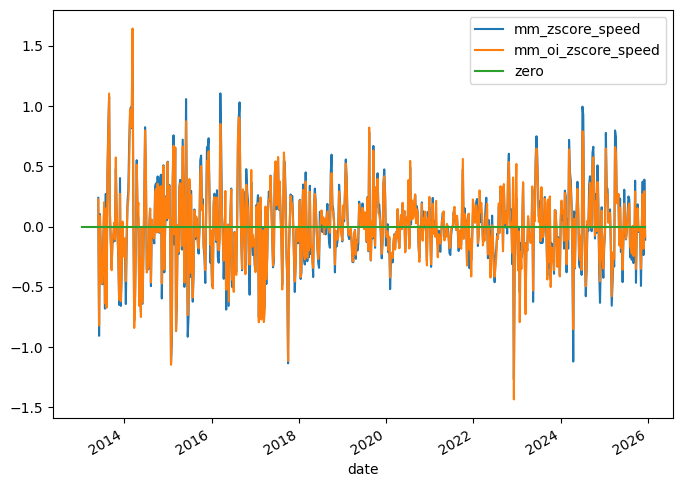

In [11]:
res['zero'] = 0
res[['mm_zscore_speed','mm_oi_zscore_speed','zero']].plot(figsize=(8,6))
# .loc['2016-01-01':'2018-01-31']


<Axes: xlabel='date'>

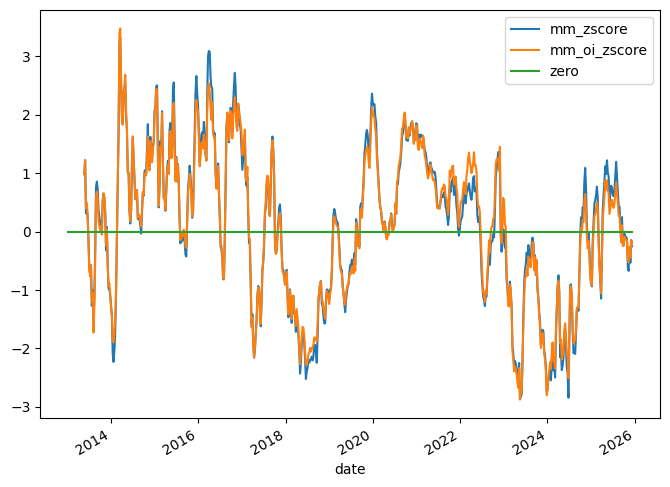

In [12]:
res[['mm_zscore','mm_oi_zscore','zero']].plot(figsize=(8,6))


In [13]:
res[['mm_zscore','legacy_non_com_zscore','cit_non_com_zscore']].quantile(0.1)

mm_zscore               -1.868850
legacy_non_com_zscore   -1.591170
cit_non_com_zscore      -1.693345
Name: 0.1, dtype: float64

In [14]:
res[['mm_zscore','legacy_non_com_zscore','cit_non_com_zscore']].quantile(0.9)

mm_zscore                1.730304
legacy_non_com_zscore    1.850463
cit_non_com_zscore       1.823451
Name: 0.9, dtype: float64

In [15]:
import pandas as pd
temp = res.copy()
def calculate_simple_ic_icir(df, signal_col, return_col, method='spearman'):
    
    if len(df) < 2:
        return np.nan, np.nan
    
    if method == 'pearson':
        ic = df[signal_col].corr(df[return_col])
    else:
        ic = df[signal_col].corr(df[return_col], method='spearman')
    
    # For ICIR: IC / std(IC) * sqrt(N)
    # Assuming you want annualized ICIR (adjust multiplier as needed)
    icir = ic / np.sqrt((1 - ic**2) / (len(df) - 2)) if abs(ic) < 1 else np.inf
    
    return ic, icir
icir_data = []
for col in temp.columns:
    
    if col in ["ret_front","ret_deferred","ret_front_sameday","ret_deferred_sameday"]:
        continue
    data = {}
    data['name'] = col

    ic, icir = calculate_simple_ic_icir(res, col, "ret_front")
    data['ic'] = ic
    data['icir'] = icir
    # print(f'{col}: IC={ic:.4f}, ICIR={icir:.4f}')
    icir_data.append(data)
icir_data = pd.DataFrame(icir_data)
icir_data = icir_data.sort_values(['ic','icir'])
icir_data = icir_data[abs(icir_data['ic']) > 0.05]
icir_data
# 

c:\Users\yuhang.hou\projects\pipeline\data_pipeline\.venv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,name,ic,icir
70,sig_seasonal_interaction,-0.089456,-2.328296
27,mm_short_share,-0.067390,-1.750923
14,cit_non_com_short,-0.065965,-1.713733
4,legacy_non_com_short,-0.065378,-1.698413
9,mm_short,-0.061811,-1.605394
71,score,-0.061691,-1.602267
11,cit_long,0.050093,1.300186
1,legacy_com_long,0.050183,1.302521
23,pmpu_long,0.056956,1.478860
7,swap_short,0.058060,1.507623


In [16]:
res[['legacy_non_com_net_oi_zscore','legacy_non_com_net_oi_zscore_speed']].corr()

,legacy_non_com_net_oi_zscore,legacy_non_com_net_oi_zscore_speed
legacy_non_com_net_oi_zscore,1.000000,0.135521
legacy_non_com_net_oi_zscore_speed,0.135521,1.000000


In [19]:
temp = res[['mm_zscore_speed', 'legacy_non_com_zscore_speed',
       'cit_non_com_zscore_speed', 'cit_zscore_speed', 'mm_desea_zscore_speed',
       'mm_net_share_desea_zscore_speed', 'cit_net_oi_zscore_speed',
       'mm_oi_zscore_speed', 'legacy_non_com_net_oi_zscore_speed',
       'cit_non_com_net_oi_zscore_speed',
    "ret_front","ret_deferred"
]]

def calculate_ic_icir(df, signal_col, return_col, method='spearman', periods_per_year=52):
    
    if len(df) < 2:
        return np.nan, np.nan, np.nan, pd.Series()
    
    if method == 'pearson':
        ic = df[signal_col].corr(df[return_col])
        ic_series = df[signal_col].rolling(min(periods_per_year, len(df))).corr(df[return_col])
    else:
        ic = df[signal_col].corr(df[return_col], method='spearman')
        window = min(periods_per_year, len(df),36)
        ic_series = pd.Series([
            df[signal_col].iloc[max(0,i-window+1):i+1].corr(
                df[return_col].iloc[max(0,i-window+1):i+1], method='spearman'
            ) for i in range(len(df))
        ], index=df.index)
        ic_series.iloc[:window-1] = np.nan
    
    ic_std = ic_series.std()
    
    if ic_std > 0:
        icir = ic / ic_std * np.sqrt(periods_per_year)  # Annualized
        ic_tstat = ic / ic_std * np.sqrt(len(df))  # Full sample t-stat
    else:
        icir = np.nan if ic == 0 else np.inf
        ic_tstat = np.nan if ic == 0 else np.inf
    
    return ic, icir, ic_tstat, ic_series
for col in temp.columns:
    if col in ["ret_front","ret_deferred"]:
        continue
    ic, icir, ic_tstat, ic_series = calculate_ic_icir(res, col, "ret_front")
    print(f'{col}: IC={ic:.4f}, ICIR={icir:.4f}, IC_TSTAT={ic_tstat:.4f}')

mm_zscore_speed: IC=-0.0163, ICIR=-0.5959, IC_TSTAT=-2.1454
legacy_non_com_zscore_speed: IC=-0.0216, ICIR=-0.7866, IC_TSTAT=-2.8319
cit_non_com_zscore_speed: IC=-0.0286, ICIR=-1.0595, IC_TSTAT=-3.8144
cit_zscore_speed: IC=0.0121, ICIR=0.4315, IC_TSTAT=1.5536
mm_desea_zscore_speed: IC=-0.0179, ICIR=-0.7118, IC_TSTAT=-2.5626
mm_net_share_desea_zscore_speed: IC=-0.0163, ICIR=-0.6631, IC_TSTAT=-2.3871
cit_net_oi_zscore_speed: IC=-0.0013, ICIR=-0.0580, IC_TSTAT=-0.2089
mm_oi_zscore_speed: IC=-0.0080, ICIR=-0.2907, IC_TSTAT=-1.0465
legacy_non_com_net_oi_zscore_speed: IC=-0.0156, ICIR=-0.5855, IC_TSTAT=-2.1078
cit_non_com_net_oi_zscore_speed: IC=-0.0229, ICIR=-0.8596, IC_TSTAT=-3.0946


In [20]:
res[['mm_zscore',
     'mm_zscore_speed',
    "sig_ad_mmt_div",
       "mm_short_share",
       'sig_ad_mmt_div_new',
"pmpu_short_share",
    'sig_seasonal_interaction',
    "sig_spread_pressure",
    "sig_cit_regime",
    'sig_front_deferred_div',
    "w_cit",
    "score",
    "ret_front","ret_deferred"
]].describe()

,mm_zscore,mm_zscore_speed,sig_ad_mmt_div,mm_short_share,sig_ad_mmt_div_new,pmpu_short_share,sig_seasonal_interaction,sig_spread_pressure,sig_cit_regime,sig_front_deferred_div,w_cit,score,ret_front,ret_deferred
count,655.000000,654.000000,655.000000,674.000000,655.000000,674.000000,655.000000,655.000000,655.000000,0.0,655.000000,655.000000,667.000000,667.000000
mean,0.100017,-0.001888,-0.189187,0.114997,-0.058262,0.527667,0.031168,0.025207,-0.080043,NaN,0.482863,-0.122819,0.000735,0.000735
std,1.309187,0.342703,2.552479,0.073856,1.055117,0.085346,2.546578,1.140780,1.159201,NaN,0.238031,1.325710,0.034354,0.034354
min,-2.871411,-1.268127,-4.604765,0.004788,-2.327055,0.316813,-9.722444,-3.165449,-2.810906,NaN,0.056738,-3.405601,-0.155659,-0.155659
25%,-0.884869,-0.196924,-2.139745,0.048880,-0.772108,0.457644,-1.146885,-0.845756,-1.000772,NaN,0.268791,-0.852249,-0.019488,-0.019488
50%,0.227893,-0.010119,-0.604831,0.101451,-0.057231,0.535980,-0.003093,-0.033536,-0.083454,NaN,0.479149,-0.188521,-0.000870,-0.000870
75%,1.025900,0.182241,1.500048,0.177312,0.675310,0.599850,1.035143,0.760172,0.743769,NaN,0.677819,0.775914,0.020848,0.020848
max,3.307436,1.494512,6.216324,0.294873,2.320907,0.715169,12.492899,3.508611,3.188055,NaN,0.960382,4.563985,0.158877,0.158877


In [21]:
# res[[
#     'close_front',
#     'mm_zscore',
#     'mm_zscore_speed',
#     "sig_ad_mmt_div",
#     "sig_spread_pressure",
#     'sig_seasonal_interaction',
#     'sig_front_deferred_div',
#     "sig_cit_regime",
#     "w_cit",
#     "score",
#     'close_deffered'
# ]].plot(subplots=True, figsize=(20, 20))
# res[[
# 'sig_ad_mmt_div_new'
    
# ]].plot( figsize=(20, 20))

array([<Axes: xlabel='date'>], dtype=object)

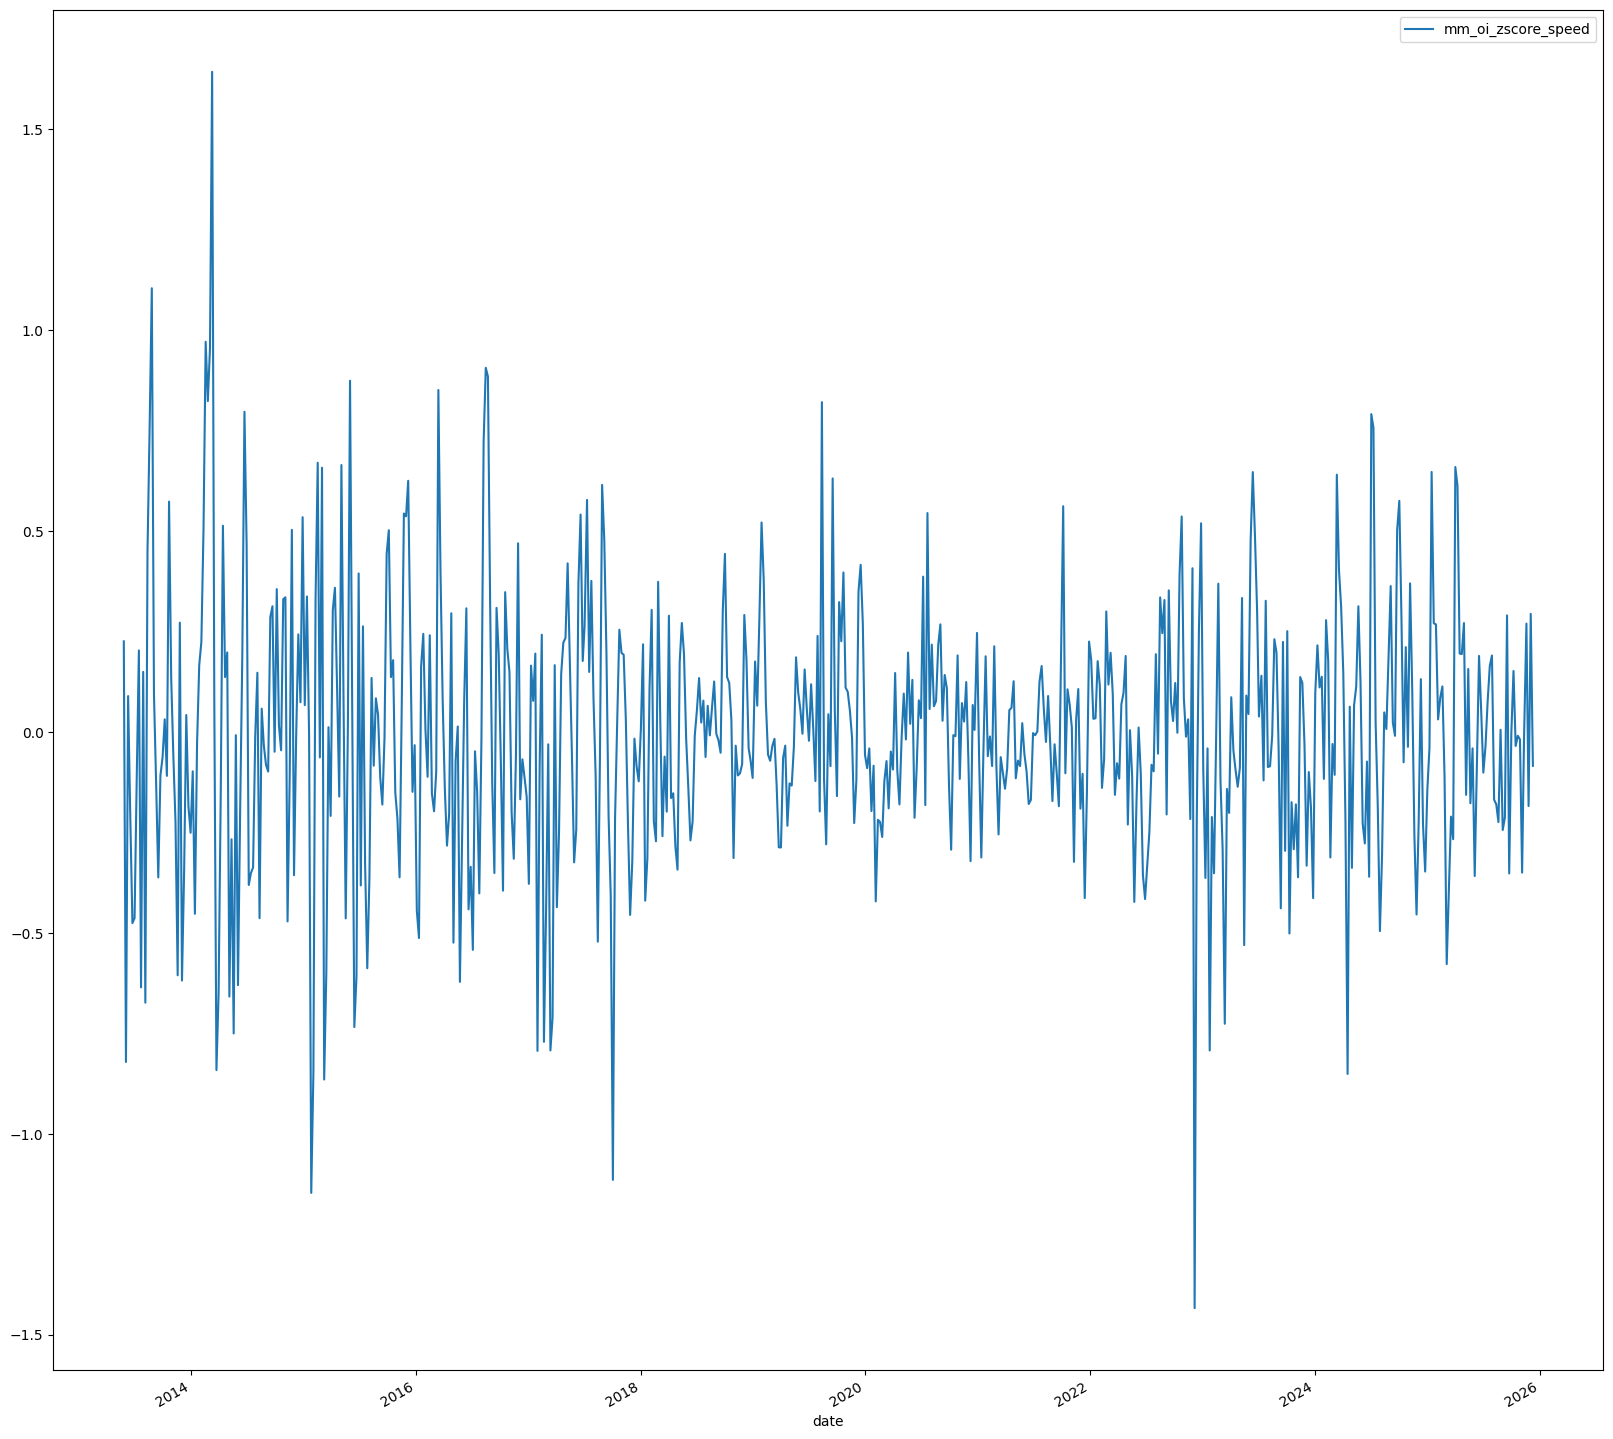

In [22]:
# res.plot()

res[['mm_oi_zscore_speed',
    ]].plot(subplots=True, figsize=(20, 20))

<Axes: xlabel='pmpu_short_share', ylabel='ret_front'>

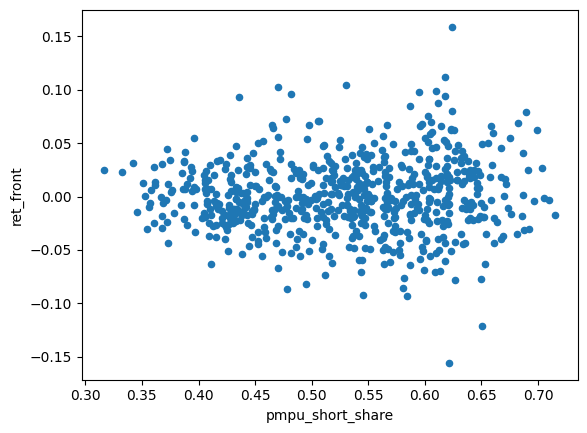

In [35]:
test = res[['mm_zscore',
    "sig_ad_mmt_div",
    'sig_seasonal_interaction',
    "sig_spread_pressure",
    "sig_cit_regime",
    'sig_front_deferred_div',
    "w_cit",
    "score",
    "ret_front","ret_deferred"
]].dropna()
res.plot.scatter(x='pmpu_short_share', y='ret_front')

<Axes: xlabel='mm_zscore', ylabel='ret_front'>

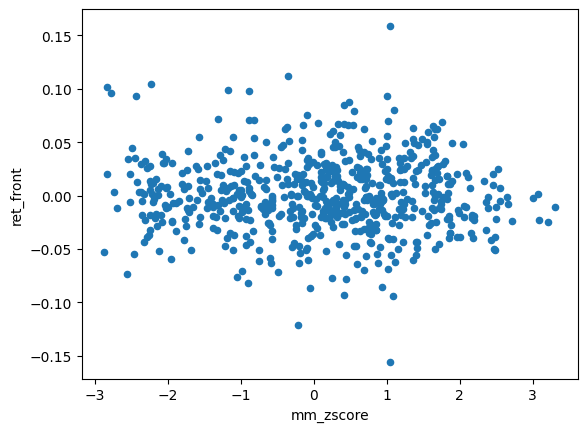

In [25]:
res.plot.scatter(x='mm_zscore', y='ret_front')

In [26]:
res[['cit_zscore_speed','ret_front']].corr()   

,cit_zscore_speed,ret_front
cit_zscore_speed,1.000000,0.012277
ret_front,0.012277,1.000000


array([[<Axes: title={'center': 'pmpu_short_share'}>]], dtype=object)

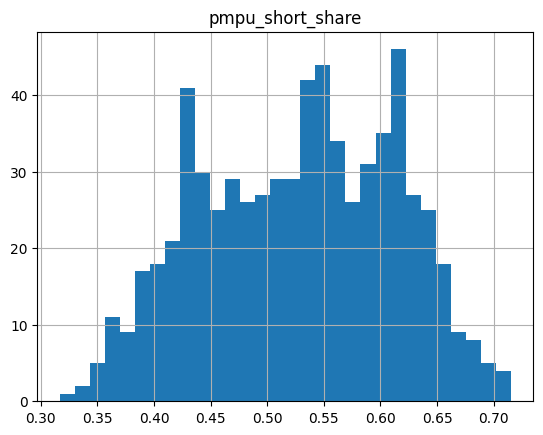

In [36]:
res.hist(column='pmpu_short_share',bins=30)

<Axes: xlabel='mm_zscore_speed', ylabel='ret_front'>

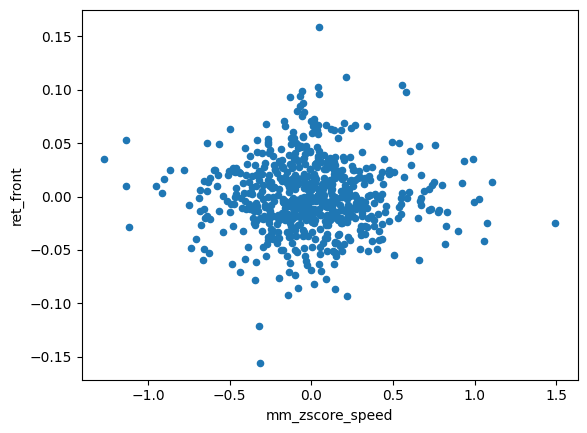

In [28]:
res.plot.scatter(x='mm_zscore_speed', y='ret_front')

In [37]:
import pandas as pd
import numpy as np

def quantile_mean_by_quantile(df, col_a, col_b, n_quantiles=10):
    df = df.copy()
    df['quantile_a'] = pd.qcut(df[col_a], n_quantiles, labels=False, duplicates='drop')
    result = df.groupby('quantile_a')[col_b].agg(['mean', 'count', 'std']).reset_index()
    result = result.rename(columns={'mean': f'mean_{col_b}'})
    return result

def quantile_mean_by_quantile_binned(df, col_a, col_b, n_quantiles=10):
    df = df.copy()
    df[f'quantile_{col_a}'] = pd.qcut(df[col_a], n_quantiles, duplicates='drop')
    quantile_stats = df.groupby(f'quantile_{col_a}')[col_b].agg(['mean', 'count', 'std']).reset_index()
    quantile_stats = quantile_stats.rename(columns={'mean': f'mean_{col_b}'})
    return quantile_stats
res1 = quantile_mean_by_quantile_binned(res, 'pmpu_short_share', 'ret_front')
res1

C:\Users\yuhang.hou\AppData\Local\Temp\ipykernel_3524\679241657.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats = df.groupby(f'quantile_{col_a}')[col_b].agg(['mean', 'count', 'std']).reset_index()


,quantile_pmpu_short_share,mean_ret_front,count,std
0,"(0.316, 0.412]",0.002732,68,0.022826
1,"(0.412, 0.442]",-0.005101,67,0.023714
2,"(0.442, 0.47]",0.000009,61,0.032832
3,"(0.47, 0.507]",-0.001504,67,0.034950
4,"(0.507, 0.536]",0.002122,67,0.030101
5,"(0.536, 0.555]",-0.002034,67,0.030445
6,"(0.555, 0.586]",-0.008720,68,0.034090
7,"(0.586, 0.61]",0.008027,67,0.041163
8,"(0.61, 0.636]",0.009713,67,0.048711
9,"(0.636, 0.715]",0.002129,68,0.035131


In [30]:
res1 = quantile_mean_by_quantile_binned(res, 'mm_oi_zscore', 'ret_front')
res1


C:\Users\yuhang.hou\AppData\Local\Temp\ipykernel_3524\3096628078.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats = df.groupby(f'quantile_{col_a}')[col_b].agg(['mean', 'count', 'std']).reset_index()


,quantile_mm_oi_zscore,mean_ret_front,count,std
0,"(-2.866, -1.785]",0.003359,66,0.035569
1,"(-1.785, -1.085]",0.003399,65,0.030162
2,"(-1.085, -0.663]",-0.006968,66,0.033336
3,"(-0.663, -0.11]",0.002270,58,0.033640
4,"(-0.11, 0.236]",-0.000564,66,0.035393
5,"(0.236, 0.552]",0.004403,65,0.034530
6,"(0.552, 0.878]",-0.008810,65,0.035338
7,"(0.878, 1.237]",0.008543,66,0.044001
8,"(1.237, 1.682]",0.008500,65,0.032682
9,"(1.682, 3.472]",-0.005870,66,0.025636


In [31]:
res1 = quantile_mean_by_quantile_binned(res, 'mm_zscore', 'ret_front')
res1


C:\Users\yuhang.hou\AppData\Local\Temp\ipykernel_3524\3096628078.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats = df.groupby(f'quantile_{col_a}')[col_b].agg(['mean', 'count', 'std']).reset_index()


,quantile_mm_zscore,mean_ret_front,count,std
0,"(-2.872, -1.869]",0.002685,66,0.035888
1,"(-1.869, -1.105]",0.002597,65,0.029085
2,"(-1.105, -0.587]",-0.005122,64,0.034613
3,"(-0.587, -0.132]",0.000594,61,0.037711
4,"(-0.132, 0.228]",0.000450,65,0.030156
5,"(0.228, 0.556]",0.007776,65,0.038155
6,"(0.556, 0.875]",-0.004977,65,0.029965
7,"(0.875, 1.235]",-0.001226,66,0.045664
8,"(1.235, 1.73]",0.011921,65,0.033579
9,"(1.73, 3.307]",-0.006666,66,0.024572


array([[<Axes: title={'center': 'mm_zscore_speed'}>]], dtype=object)

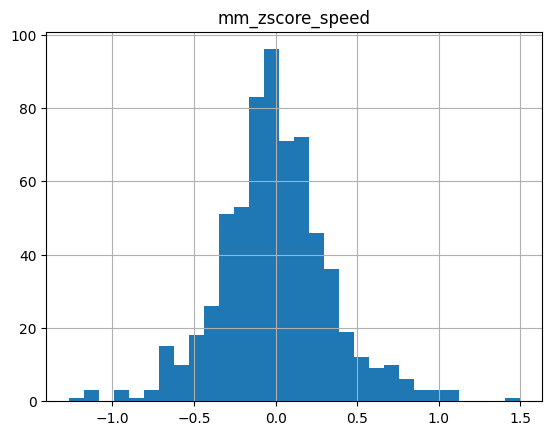

In [32]:
res.hist(column='mm_zscore_speed',bins=30)

In [33]:
res[['mm_zscore_speed','ret_front']].corr()   

,mm_zscore_speed,ret_front
mm_zscore_speed,1.000000,0.001893
ret_front,0.001893,1.000000


In [34]:
res[['legacy_com_net_share','ret_front']].corr()

,legacy_com_net_share,ret_front
legacy_com_net_share,1.000000,-0.023503
ret_front,-0.023503,1.000000
